# 청년 인구 순유출 분석 — STEP 1: 전국 시군구 청년 순유출 현황

## 개요
KOSIS(국가통계포털)의 시군구별·성별·연령별 순이동 통계를 활용해, 전국 시군구 단위에서
청년층(19-34세)의 순유출 현황을 분석한다.

- 데이터 출처: KOSIS 국내인구이동통계 (시군구/성/연령별 순이동)
- 분석 기간: 2015~2025
- 원자료 형식: wide format (연도가 컬럼), cp949 인코딩


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print(os.getcwd())

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('/Users/bbungchu/Desktop/청년 지역 이탈 프로젝트/youth-population-outflow-analysis/data/raw/kosis_sgg_sex_age_net_migration_raw.csv', encoding='cp949')

df

/Users/bbungchu/Desktop/청년 지역 이탈 프로젝트/youth-population-outflow-analysis/notebooks


,행정구역(시군구)별,성별,연령별,항목,단위,2015 년,2016 년,2017 년,2018 년,2019 년,2020 년,2021 년,2022 년,2023 년,2024 년,2025 년,Unnamed: 16
0,서울특별시,남자,계,순이동[명],명,-74154.0,-74941.0,-55418.0,-62557.0,-33562.0,-41379.0,-58722.0,-22207.0,-20920,-26467.0,-18077.0,NaN
1,서울특별시,남자,0 - 4세,순이동[명],명,-8122.0,-8615.0,-6960.0,-7929.0,-4995.0,-4627.0,-4745.0,-3570.0,-3393,-3352.0,-2577.0,NaN
2,서울특별시,남자,5 - 9세,순이동[명],명,-3520.0,-3862.0,-2765.0,-3787.0,-1626.0,-2263.0,-2890.0,-1462.0,-721,-522.0,335.0,NaN
3,서울특별시,남자,10 - 14세,순이동[명],명,-1369.0,-1721.0,-896.0,-1338.0,-346.0,-812.0,-1310.0,-204.0,-35,105.0,316.0,NaN
4,서울특별시,남자,15 - 19세,순이동[명],명,-1147.0,-1294.0,-171.0,-312.0,653.0,-101.0,-689.0,1762.0,1624,1945.0,2182.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10293,국외 및 기타,여자,65 - 69세,순이동[명],명,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
10294,국외 및 기타,여자,70 - 74세,순이동[명],명,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
10295,국외 및 기타,여자,75 - 79세,순이동[명],명,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN
10296,국외 및 기타,여자,80세이상,순이동[명],명,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN


## 1. 데이터 불러오기

In [2]:
df = pd.read_csv(
    "../data/raw/kosis_sgg_sex_age_net_migration_raw.csv",
    encoding="cp949"
)
year_cols = [col for col in df.columns if "년" in col]
for c in year_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("원본 행 수:", len(df))
df.head()

원본 행 수: 10298


,행정구역(시군구)별,성별,연령별,항목,단위,2015 년,2016 년,2017 년,2018 년,2019 년,2020 년,2021 년,2022 년,2023 년,2024 년,2025 년,Unnamed: 16
0,서울특별시,남자,계,순이동[명],명,-74154.0,-74941.0,-55418.0,-62557.0,-33562.0,-41379.0,-58722.0,-22207.0,-20920,-26467.0,-18077.0,NaN
1,서울특별시,남자,0 - 4세,순이동[명],명,-8122.0,-8615.0,-6960.0,-7929.0,-4995.0,-4627.0,-4745.0,-3570.0,-3393,-3352.0,-2577.0,NaN
2,서울특별시,남자,5 - 9세,순이동[명],명,-3520.0,-3862.0,-2765.0,-3787.0,-1626.0,-2263.0,-2890.0,-1462.0,-721,-522.0,335.0,NaN
3,서울특별시,남자,10 - 14세,순이동[명],명,-1369.0,-1721.0,-896.0,-1338.0,-346.0,-812.0,-1310.0,-204.0,-35,105.0,316.0,NaN
4,서울특별시,남자,15 - 19세,순이동[명],명,-1147.0,-1294.0,-171.0,-312.0,653.0,-101.0,-689.0,1762.0,1624,1945.0,2182.0,NaN


## 2. 데이터 품질 진단 및 정제

원본 데이터를 그대로 사용할 경우 세 가지 문제가 있다.

1. **유령 행**: 마산시·진해시(2010년 창원시 통합), 여천시·여천군(1998년 여수시 통합) 등
   2015년 이전에 이미 폐지·통합된 옛 행정구역 코드가 남아 있으며, 분석 기간 전체 값이 0/결측이다.
2. **행정구역 관할 변경**: 군위군은 2023년 7월 1일 경상북도에서 대구광역시로 편입되어,
   데이터가 2015-2022(경북 관할)와 2023-2025(대구 관할)로 분리되어 있다.
3. **구/군 이름 중복**: 원본 표에 상위 시/도 컬럼이 없고, "중구", "동구", "남구" 등
   여러 광역시에서 반복되는 구 이름이 행 순서로만 구분되어 있다. 이름만으로 집계하면
   서로 다른 도시의 동명 구가 합산되는 오류가 발생한다 (예: 서울 중구 + 울산 중구가
   하나의 "중구"로 잘못 합산됨).

아래에서 상위 행정구역(parent) 컬럼을 복원하고, 유령 행을 제거하며,
군위군의 분리된 시계열을 현재 관할(대구광역시) 기준으로 병합한다.

In [3]:
parents = ['서울특별시','부산광역시','대구광역시','인천광역시','광주광역시','대전광역시',
           '울산광역시','세종특별자치시','경기도','강원도','강원특별자치도','충청북도','충청남도',
           '전라북도','전북특별자치도','전라남도','경상북도','경상남도','제주특별자치도']

# 시/도 행이 나올 때마다 갱신, 그 사이 구/군 행에는 forward fill로 소속 부여
df["parent"] = df["행정구역(시군구)별"].where(df["행정구역(시군구)별"].isin(parents)).ffill()
df["is_parent_row"] = df["행정구역(시군구)별"].isin(parents)

df[["parent", "행정구역(시군구)별", "is_parent_row"]].head(30)

,parent,행정구역(시군구)별,is_parent_row
0,서울특별시,서울특별시,True
1,서울특별시,서울특별시,True
2,서울특별시,서울특별시,True
3,서울특별시,서울특별시,True
4,서울특별시,서울특별시,True
5,서울특별시,서울특별시,True
6,서울특별시,서울특별시,True
7,서울특별시,서울특별시,True
8,서울특별시,서울특별시,True
9,서울특별시,서울특별시,True


In [4]:
# 전 기간(2015~2025) 완전 0/결측인 유령 행 탐지
ghost_regions = (
    df.groupby("행정구역(시군구)별")[year_cols]
    .apply(lambda g: (g.fillna(0) == 0).all().all())
)
ghost_list = ghost_regions[ghost_regions].index.tolist()
print(f"유령 행 제거 대상: {len(ghost_list)}개")
print(ghost_list)

df = df[~df["행정구역(시군구)별"].isin(ghost_list)].copy()
print("제거 후 행 수:", len(df))

유령 행 제거 대상: 22개
['광주군', '국외 및 기타', '김포군', '남제주군', '논산군', '당진군', '마산시', '북제주군', '시흥군', '안성군', '양산군', '양주군', '여천군', '여천시', '연기군', '용인군', '울산시', '이천군', '진해시', '파주군', '포천군', '화성군']
제거 후 행 수: 9462


### 군위군 관할 변경 병합

군위군은 2023.7.1 대구광역시로 편입되었다. 편입 시점 데이터에는 이전 관할(경상북도) 쪽
2023년 값이 0으로, 신규 관할(대구광역시) 쪽 2015-2022년 값이 결측(NaN)으로 남아 있어,
이 둘을 하나의 지역으로 간주하고 현재 관할 기준으로 통합한다. 병합 시 경계 연도의 0은
실제 값이 아닌 관할 이관에 따른 플레이스홀더로 판단하여 결측 처리 후 병합했다.

In [5]:
mask_gunwi = df["행정구역(시군구)별"] == "군위군"
df.loc[mask_gunwi, "parent"] = "대구광역시"
df.loc[mask_gunwi, year_cols] = df.loc[mask_gunwi, year_cols].replace(0, np.nan)

gunwi_merged = (
    df[mask_gunwi]
    .groupby(["parent", "행정구역(시군구)별", "성별", "연령별"], as_index=False)[year_cols]
    .sum(min_count=1)
)
gunwi_merged["is_parent_row"] = False

df = pd.concat([df[~mask_gunwi], gunwi_merged], ignore_index=True)
print("병합 후 행 수:", len(df))

병합 후 행 수: 9424


In [6]:
# 검증: parent+region 조합 기준 고유 시군구 수, 이름만으로 셌을 때와 비교
combo = df[~df["is_parent_row"]][["parent", "행정구역(시군구)별"]].drop_duplicates()
print("이름 기준 고유 지역 수:", df[~df["is_parent_row"]]["행정구역(시군구)별"].nunique())
print("parent+이름 기준 고유 지역 수:", len(combo))

# 동명 구 중복 사례 확인 (예: 중구)
combo[combo["행정구역(시군구)별"] == "중구"]

이름 기준 고유 지역 수: 211
parent+이름 기준 고유 지역 수: 229


,parent,행정구역(시군구)별
76,서울특별시,중구
2926,울산광역시,중구


## 3. 전처리: long format 변환 및 청년층 추출

시/도 자체 합계 행(`is_parent_row=True`)은 시군구 단위 분석에서 제외한다. 이 행들을 포함하면
"서울특별시"(광역 합계)와 "강남구"(구 단위)가 같은 랭킹에서 비교되는 단위 불일치 문제가 생긴다.

In [7]:
df_sgg = df[~df["is_parent_row"]].copy()

df_long = df_sgg.melt(
    id_vars=["parent", "행정구역(시군구)별", "성별", "연령별"],
    value_vars=year_cols,
    var_name="year",
    value_name="net_migration"
)
df_long = df_long.rename(columns={
    "행정구역(시군구)별": "region",
    "성별": "sex",
    "연령별": "age_group"
})
df_long["year"] = df_long["year"].str.replace(" 년", "", regex=False).astype(int)
df_long.head()

,parent,region,sex,age_group,year,net_migration
0,서울특별시,종로구,남자,계,2015,-1276.0
1,서울특별시,종로구,남자,0 - 4세,2015,-50.0
2,서울특별시,종로구,남자,5 - 9세,2015,-4.0
3,서울특별시,종로구,남자,10 - 14세,2015,-15.0
4,서울특별시,종로구,남자,15 - 19세,2015,44.0


In [8]:
df_youth = df_long[df_long["age_group"] == "청년층(19-34세)"].copy()
df_youth = df_youth.dropna(subset=["net_migration"]).copy()

print(df_youth.shape)
df_youth.isna().sum()

(5060, 6)


parent           0
region           0
sex              0
age_group        0
year             0
net_migration    0
dtype: int64

성별 데이터를 합산해 지역 단위 순이동으로 집계한다. 지역은 `parent`(상위 시/도)와
`region`(시군구명)을 함께 사용해 동명 구 문제를 피한다.
(성별에 따른 이동 패턴 차이는 이후 STEP3 이동 사유 분석에서 별도로 다룬다)

In [9]:
df_youth_total = (
    df_youth.groupby(["year", "parent", "region"], as_index=False)["net_migration"].sum()
)
df_youth_total["region_full"] = df_youth_total["parent"] + " " + df_youth_total["region"]
df_youth_total.head()

,year,parent,region,net_migration,region_full
0,2015,강원특별자치도,강릉시,-1378.0,강원특별자치도 강릉시
1,2015,강원특별자치도,고성군,-367.0,강원특별자치도 고성군
2,2015,강원특별자치도,동해시,-585.0,강원특별자치도 동해시
3,2015,강원특별자치도,삼척시,-1517.0,강원특별자치도 삼척시
4,2015,강원특별자치도,속초시,-296.0,강원특별자치도 속초시


## 4. 전처리 결과 저장

이후 단계에서 재사용할 수 있도록 전처리된 데이터를 저장한다.

In [10]:
df_youth_total.to_csv(
    "../data/processed/youth_net_migration_processed.csv",
    index=False,
    encoding="utf-8-sig"
)
print("저장 완료, 행 수:", len(df_youth_total))

저장 완료, 행 수: 2519


## STEP 1. 전체 기간 누적 순이동 분석

2015~2025 동안 청년 순유출이 가장 큰 지역을 파악한다.
단, 이는 절대값 기준이므로 인구 규모가 큰 지역일수록 유출 규모도 커지는 경향이 있다는 점에
유의한다. 지역별 청년 인구 대비 순유출률은 인구 데이터를 결합한 이후 별도로 검증할 예정이다.

In [11]:
region_total = (
    df_youth_total.groupby("region_full")["net_migration"]
    .sum()
    .sort_values()
)
region_total.head(10)

region_full
경상남도 창원시      -49887.0
대구광역시 달서구     -42319.0
대구광역시 수성구     -40044.0
경기도 안산시       -33140.0
서울특별시 노원구     -29573.0
서울특별시 양천구     -28008.0
경기도 부천시       -27911.0
전북특별자치도 전주시   -23442.0
부산광역시 해운대구    -23246.0
인천광역시 계양구     -22956.0
Name: net_migration, dtype: float64

### 연도별 순유출 상위 지역

연도에 따라 순유출 상위 지역이 어떻게 변화하는지 확인한다.
누적 기준 상위 지역과 최근 연도 기준 상위 지역이 일치하는지 비교한다.

In [12]:
yearly_outflow = (
    df_youth_total
    .sort_values(["year", "net_migration"])
    .groupby("year")
    .head(10)
)
yearly_outflow

,year,parent,region,net_migration,region_full
125,2015,서울특별시,강동구,-5470.0,서울특별시 강동구
101,2015,대구광역시,수성구,-3955.0,대구광역시 수성구
61,2015,경상남도,창원시,-3902.0,경상남도 창원시
132,2015,서울특별시,노원구,-3495.0,서울특별시 노원구
32,2015,경기도,안산시,-3438.0,경기도 안산시
...,...,...,...,...,...
2382,2025,광주광역시,북 구,-2839.0,광주광역시 북 구
2432,2025,서울특별시,양천구,-2557.0,서울특별시 양천구
2462,2025,전라남도,목포시,-2326.0,전라남도 목포시
2386,2025,대구광역시,달서구,-2325.0,대구광역시 달서구


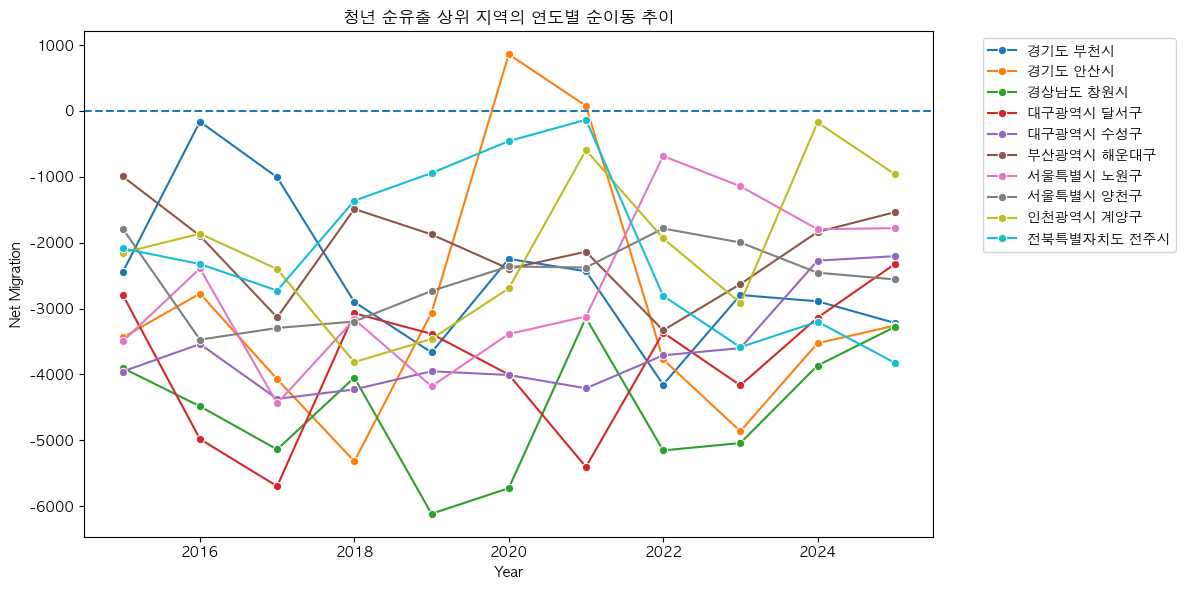

In [13]:
top_outflow_regions = region_total.head(10).index
df_top_outflow = df_youth_total[df_youth_total["region_full"].isin(top_outflow_regions)]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_top_outflow,
    x="year",
    y="net_migration",
    hue="region_full",
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.title("청년 순유출 상위 지역의 연도별 순이동 추이")
plt.xlabel("Year")
plt.ylabel("Net Migration")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 인사이트

[대구 달서구/수성구, 경남 창원시 등이 상위를 차지하지만 이는 인구 규모 효과일 가능성이 있어 다음 단계에서 인구 대비 순유출률로 재검증 필요]